In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from numpy.typing import NDArray
from typing import List, Tuple, Optional, Dict
import logging
from numpy import ma

# Continuum removal from snid apodize.py

In [2]:
def meanzero(y: np.ndarray, ioff: int = 0, nedge: int = 1)-> tuple[np.ndarray, np.ndarray, int, np.ndarray, np.ndarray]:
    """
    Fit a spline to the spectrum and normalize by dividing it out.
    
    Parameters:
    -----------
    y : np.ndarray
        Input flux array
    ioff : int
        Offset for picking knots if > 0
    nedge : int
        Number of edge pixels to ignore
    
    Returns:
    --------
    tuple: (ynorm, ynorm, l1, l2, nknot, xknot, yknot)
        Normalized array, modified normalized array, start/end indices,
        number of knots, knot x-positions, knot y-positions
    """
    import pylab as plt
    #print("meanzero")
    n = len(y)
    KNOTCHOICE = 2  # 1 = maximum, 2 = average
    KNOTNUM = 13    # Normal number of knots over N pixels
    MAXKNOT = 20
    
    # Copy the array
    ynorm = y.copy()
    
    # Find the range of non-zero data values, ignoring edge pixels
    l1 = 0
    nuke = 0
    while l1 < n and (y[l1] <= 0 or nuke < nedge):
        if abs(y[l1]) > 0:
            nuke += 1
        ynorm[l1] = 0
        l1 += 1
    
    l2 = n - 1
    nuke = 0
    while l2 > 0 and (y[l2] <= 0 or nuke < nedge):
        if abs(y[l2]) > 0:
            nuke += 1
        ynorm[l2] = 0
        l2 -= 1
    
    if l2 - l1 < 3 * KNOTNUM:
        print('MEANZERO: This spectrum is zero or negative!')
        return ynorm, l1, l2, 0, np.array([]), np.array([])
    
    # Choose knots based on selection method
    if KNOTCHOICE == 1:
        # Pick maximum values in bins
        nknot = max(5, (KNOTNUM * (l2 - l1)) // n)
        xknot = np.zeros(nknot)
        yknot = np.zeros(nknot)
        
        for k in range(nknot):
            if k == 0:
                i1 = l1
                i2 = l1
            elif k == nknot - 1:
                i1 = l2
                i2 = l2
            else:
                i1 = int((k - 1.5) * (l2 - l1 + 1) / (nknot - 1) + l1)
                i2 = int((k - 0.5) * (l2 - l1 + 1) / (nknot - 1) + l1 - 1)
            
            biggie = -500
            for i in range(i1, i2 + 1):
                if y[i] > biggie:
                    xknot[k] = i
                    yknot[k] = np.log10(y[i])
                    biggie = y[i]
    
    elif KNOTCHOICE == 2:
        # Use average values in bins
        kwidth = n // KNOTNUM
        istart = 0
        if ioff > 0:
            istart = (ioff % kwidth) - kwidth
        
        # Collect knot positions
        knots_x = []
        knots_y = []
        
        nave = 0
        wave_sum = 0
        fave_sum = 0
        istart = 0
        if ioff > 0:
            istart = (ioff % kwidth) - kwidth
        
        for i in range(n):
            if i > l1 and i < l2:
                nave += 1
                wave_sum += i - 0.5
                fave_sum += y[i]
            
            if (i - istart) % kwidth == 0:
                if nave > 0 and fave_sum > 0:
                    knots_x.append(wave_sum / nave)
                    knots_y.append(np.log10(fave_sum / nave))
                
                nave = 0
                wave_sum = 0
                fave_sum = 0
        
        nknot = len(knots_x)
        xknot = np.array(knots_x)
        yknot = np.array(knots_y)
    
    else:
        raise ValueError('MEANZERO: must make a choice for KNOTCHOICE')
    
    # Calculate spline (simplified - using cubic spline interpolation)
    if nknot < 4:
        # Fall back to linear interpolation for few points
        from scipy.interpolate import interp1d
        spline_interp = interp1d(xknot, yknot, kind='linear', 
                                fill_value='extrapolate')
    else:
        from scipy.interpolate import CubicSpline
        spline_interp = CubicSpline(xknot, yknot, extrapolate=True)
    
    # Evaluate the spline at each point, divide and subtract 1
    for i in range(l1, l2 + 1):
        spl = spline_interp(i - 0.5)
        # plt.plot(i, y[i], 'x')
        ynorm[i] = y[i] / (10.0 ** spl) - 1
        #plt.plot(i, ynorm[i], 'x')
    #plt.title("spline")
    #plt.show()
        
    return ynorm, spline_interp, l1, l2, nknot, xknot, yknot

 # from: https://github.com/FiorenSt/SNID-SAGE/blob/main/snid_sage/snid/preprocessing.py#L437 

In [33]:
def fit_continuum(
    flux: NDArray[np.floating],
    *,
    method: str = "spline",
    # spline args:
    knotnum: int = 13,
    izoff:    int = 0,
    edge_guard_frac: float = 0.02,
) -> Tuple[NDArray[np.floating], NDArray[np.floating]]:
    """
    Remove a smooth continuum from `flux` on the fixed log‐λ grid.

    Returns
    -------
    flat : flux/cont - 1
    cont : continuum estimate

    Parameters
    ----------
    method : "spline"
       - "spline": use the original SNID cubic‐spline (fit_continuum_spline) (DEFAULT)
    knotnum, izoff
      passed to fit_continuum_spline
    """
    if method == "spline":
        flat, cont = fit_continuum_spline(
            flux,
            knotnum=knotnum,
            izoff=izoff,
            edge_guard_frac=edge_guard_frac,
        )
    else:
        raise ValueError(f"Unknown method={method!r}; only 'spline' is supported")

    # ——— zero‐out anything outside the observed data range ———
    # find first/last valid data bins (including negative values for continuum-subtracted spectra)
    valid_indices = np.where((flux != 0) & np.isfinite(flux))[0]

   
    
    if valid_indices.size:
        i0, i1 = valid_indices[0], valid_indices[-1]
        # outside [i0,i1] we have no data → zero flat, unity continuum
        flat[:i0]   = 0.0
        flat[i1+1:] = 0.0
        cont[:i0]   = 0.0
        cont[i1+1:] = 0.0

    return flat, cont



def fit_continuum_spline(
    flux: NDArray[np.floating],
    knotnum: int = 13,
    izoff:    int = 0,
    *,
    edge_guard_frac: float = 0.02,
) -> Tuple[NDArray[np.floating], NDArray[np.floating]]:
    """
    Continuum removal and scaling steps:
      1) find usable range [l1..l2] by chopping off up to one zero
         or negative pixel at each end,
      2) place knots by averaging within kw = n//knotnum bins,
         with a phase offset istart = (izoff % kw) - kw,
      3) build a natural cubic spline through (xknot, yknot) in log10,
      4) evaluate the spline to get cont[i] = 10**spl(i),
      5) return flat = flux/cont - 1, plus cont itself.
    Parameters
    ----------
    flux : 1D array of flux (must be ≥0 for real data points)
    knotnum : number of average-knots
    izoff   : integer offset in log-bins
    Returns
    -------
    flat : flux with continuum removed (flat[i] = flux[i]/cont[i] - 1)
    cont : the continuum model sampled at every i (same shape as flux)
    """
    n = flux.size

    # trivial case
    if n < 10 or knotnum < 3:
        print('MEANZERO: n < 10 or knotnum < 3')
        return np.zeros_like(flux), np.ones_like(flux)
        #error should be raised here

    # --- 1) chop off up to one zero/neg at each end ---
    l1 = 0
    nuked = 0
    while l1 < n - 1 and (flux[l1] <= 0 or nuked < 1):
        if flux[l1] > 0:
            nuked += 1
        l1 += 1

    l2 = n - 1
    nuked = 0
    while l2 > 1 and (flux[l2] <= 0 or nuked < 1):
        if flux[l2] > 0:
            nuked += 1
        l2 -= 1

    if (l2 - l1) < 3 * knotnum:
        return np.zeros_like(flux), np.ones_like(flux)
        print('MEANZERO: This spectrum is zero or negative! (l2 - l1) < 3 * knotnum')

    # --- 2) place knots using robust averages ---
    #
    # Edge-guard: spectrum ends are often junk (throughput roll-off / extraction artifacts).
    # We avoid letting the first/last knots be anchored to those bins by shrinking the
    # knot-placement window inside the usable region [l1..l2]. We still evaluate the spline
    # everywhere (full log grid); this only affects knot placement.
    usable = int(max(0, (l2 - l1 + 1)))
    try:
        eg = float(edge_guard_frac)
    except Exception:
        eg = 0.0
    eg = max(0.0, min(0.2, eg))  # keep it sane; 0.02 default
    guard = int(round(eg * usable))
    # Avoid guarding away too much (keep >= ~1/3 usable span)
    guard = max(0, min(guard, max(0, usable // 3)))
    l1_knot = int(l1 + guard)
    l2_knot = int(l2 - guard)
    # If we made the window too small to support knots, fall back to original.
    if (l2_knot - l1_knot) < 3 * knotnum:
        l1_knot, l2_knot = int(l1), int(l2)

    # Use log10(mean(flux)) per block (NOT mean(log10(flux))).
    kwidth = n // knotnum
    istart = ((izoff % kwidth) - kwidth) if izoff > 0 else 0

    xknot = []
    yknot = []
    nave = 0.0
    sum_x = 0.0
    sum_flux = 0.0

    for i in range(n):
        if l1_knot < i < l2_knot and flux[i] > 0:
            nave += 1.0
            sum_x += (i - 0.5)
            sum_flux += flux[i]
        if ((i - istart) % kwidth) == 0 and nave > 0:
            xknot.append(sum_x / nave)
            yknot.append(np.log10(sum_flux / nave))
            nave = 0.0
            sum_x = 0.0
            sum_flux = 0.0

    nk = len(xknot)
    if nk < 3:
        return np.zeros_like(flux), np.ones_like(flux)
        print('MEANZERO: nk < 3')

    xknot = np.array(xknot, dtype=float)
    yknot = np.array(yknot, dtype=float)


    # --- 3) build spline second derivatives y2 ---
    h = np.diff(xknot)
    rhs = 6.0 * (
        (yknot[2:] - yknot[1:-1]) / h[1:]
      - (yknot[1:-1] - yknot[:-2]) / h[:-1]
    )
    A = 2.0 * (h[:-1] + h[1:])
    C = h[1:]

    u = np.empty_like(A)
    z = np.empty_like(rhs)
    u[0], z[0] = A[0], rhs[0]
    for i in range(1, len(rhs)):
        li = C[i-1] / u[i-1]
        u[i]  = A[i] - li * C[i-1]
        z[i]  = rhs[i] - li * z[i-1]

    y2 = np.zeros(nk, dtype=float)
    if len(rhs) > 0:
        y2[-2] = z[-1] / u[-1]
        for i in range(len(rhs)-2, -1, -1):
            y2[i+1] = (z[i] - C[i] * y2[i+2]) / u[i]


    # --- 4) evaluate spline to get continuum cont ---
    cont = np.empty(n, dtype=float)
    for j in range(n):
        xp = j - 0.5
        idx = np.clip(np.searchsorted(xknot, xp) - 1, 0, nk-2)
        h_i = xknot[idx+1] - xknot[idx]
        a = (xknot[idx+1] - xp) / h_i
        b = (xp - xknot[idx])   / h_i
        logc = (
            a * yknot[idx]
          + b * yknot[idx+1]
          + ((a**3 - a)*y2[idx] + (b**3 - b)*y2[idx+1]) * (h_i**2) / 6.0
        )
        with np.errstate(over='ignore'):
            cont[j] = float(np.power(10.0, logc))


    # --- 5) form normalized residuals ---
    flat = np.zeros_like(flux)
    mask = (flux > 0) & (cont > 0)
    flat[mask] = flux[mask] / cont[mask] - 1.0

    return flat, cont

# Testing the continuum removal

In [4]:
def positive_flux(y_nonoise, y, eps = 1e-6):
    if sum(y_nonoise<=0) > 0:
        const = eps - min(y_nonoise) 
        y = y + const
        y_nonoise = y_nonoise + const
    if sum(y<=0) > 0:
        const = eps - min(y) 
        y = y + const
        y_nonoise = y_nonoise + const
    return y_nonoise, y

In [5]:
parabola = lambda x, a, b, c: a*x**2 + b*x + c

In [6]:
data_size = 100

rng = np.random.default_rng(seed=7)
noise = np.random.normal(loc=0, scale=1, size=(data_size))
x = np.linspace(0,10, num = data_size)

In [7]:
# Test with parabola with noise 
y_nonoise = parabola(x,-0.2,5,10)
y = y_nonoise+noise
y_nonoise, y = positive_flux(y_nonoise, y)


# meanzero
ynorm, spline_interp, l1, l2, nknot, xknot, yknot = meanzero(y, nedge =2)
# snid sage
flat_sage, cont_sage = fit_continuum(y)

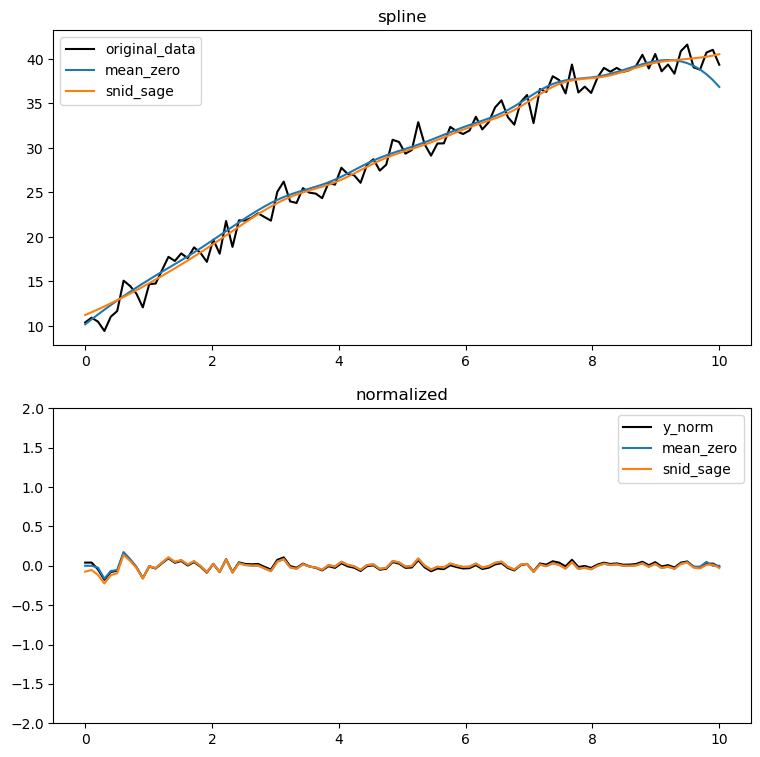

In [8]:
# plots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(9, 9))
ax1.plot(x, y, label= "original_data", c= "k")
ax2.plot(x, (y/y_nonoise) -1, label="y_norm", c= "k")

ax2.set_ylim(-2,2)
ax1.set_title("spline")
ax2.set_title("normalized")

# meanzero
ax1.plot(x, 10**spline_interp(np.arange(0.5,data_size)), label = "mean_zero") 
ax2.plot(x, ynorm, label = "mean_zero")

# snid sage
ax1.plot(x, cont_sage, label = "snid_sage")
ax2.plot(x, flat_sage, label = "snid_sage")


ax1.legend()
ax2.legend()

In [9]:
# Test with 4th order polynomial with noise 
y_nonoise = np.polyval([.2,-.8,-.1,5], x)
noise = np.random.normal(loc=0, scale=.2, size=(data_size))
y = y_nonoise +noise
y_nonoise, y = positive_flux(y_nonoise, y)

# meanzero
ynorm, spline_interp, l1, l2, nknot, xknot, yknot = meanzero(y, nedge =2)
# snid sage
flat_sage, cont_sage = fit_continuum(y)

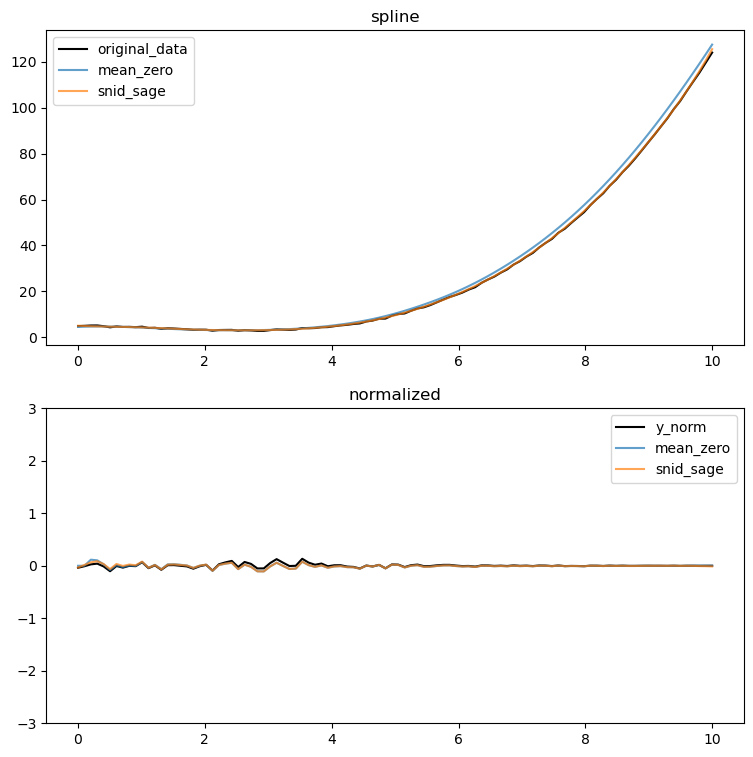

In [10]:
# plots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(9, 9))
ax1.plot(x, y, c = "k", label= "original_data")
ax2.plot(x, y/y_nonoise -1, c = "k", label="y_norm")

ax2.set_ylim(-3,3)
ax1.set_title("spline")
ax2.set_title("normalized")

# meanzero
ax1.plot(x, 10**spline_interp(np.arange(0.5,data_size)), label = "mean_zero", alpha = 0.7) 
ax2.plot(x, ynorm, label = "mean_zero", alpha = 0.7)

# snid sage
ax1.plot(x, cont_sage, label = "snid_sage", alpha = 0.7)
ax2.plot(x, flat_sage, label = "snid_sage", alpha = 0.7)


ax1.legend()
ax2.legend()

In [11]:
def gaussian(x, A, sigma, mu):
    """
        Model a Gaussian distribution.

        Parameters:
            x (array-like): Independent variable (e.g., wavelength or frequency).
            A (float): Amplitude of the distribution
            mu (float): Central position of the distribution
            sigma (float): standard deviation
    .

        Returns:
            array-like: Gaussian distribution values at the specified x values.
    """
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

In [21]:
# Test with 4th order polynomial with noise and features
x = np.linspace(0,5, num = data_size)

features = gaussian(x, -5, .1, 2) + gaussian(x, -2, .1, 1) + gaussian(x, -2, .1, 4.5)
noise = np.random.normal(loc=0, scale=1, size=(data_size))
continuum = np.polyval([.1,-.6,-.2,2.2,1.5], x)
y = continuum + noise + features
continuum, y = positive_flux(continuum, y)

# meanzero
ynorm, spline_interp, l1, l2, nknot, xknot, yknot = meanzero(y, nedge =4)
# snid sage
flat_sage, cont_sage = fit_continuum(y, knotnum = 13)

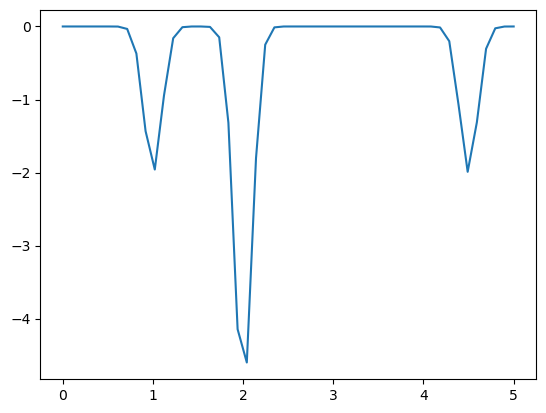

In [22]:
plt.plot(x, features)

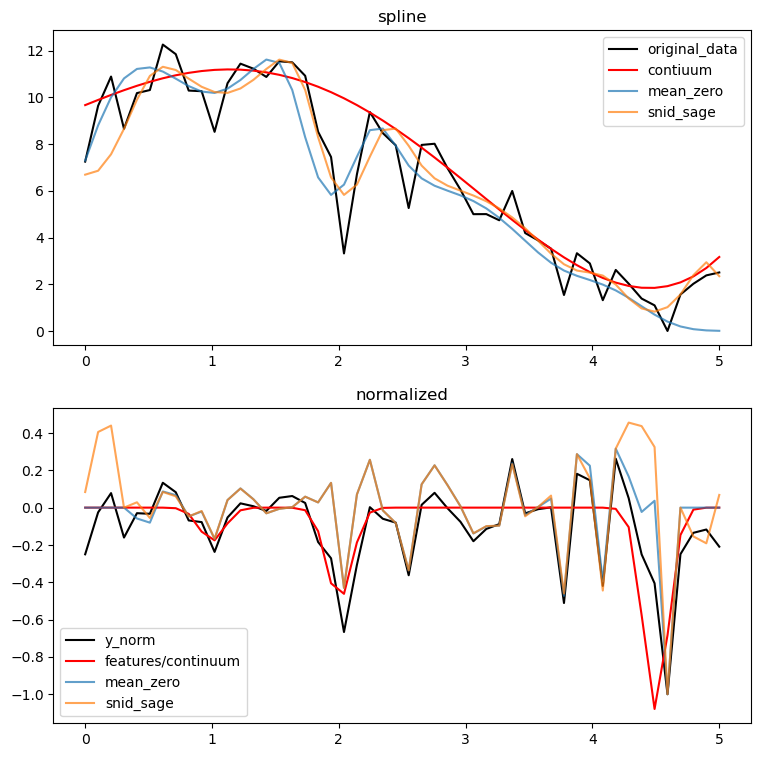

In [23]:
# plots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(9, 9))
ax1.plot(x, y, c = "k", label= "original_data")
ax1.plot(x, continuum, c = "r", label= "contiuum")
ax2.plot(x, y/continuum -1, c = "k", label="y_norm")
ax2.plot(x, features/continuum , c = "r", label="features/continuum")

#ax2.set_ylim(-3,3)
ax1.set_title("spline")
ax2.set_title("normalized")

# meanzero
ax1.plot(x, 10**spline_interp(np.arange(0.5,data_size)), label = "mean_zero", alpha = 0.7) 
ax2.plot(x, ynorm, label = "mean_zero", alpha = 0.7)

# snid sage
ax1.plot(x, cont_sage, label = "snid_sage", alpha = 0.7)
ax2.plot(x, flat_sage, label = "snid_sage", alpha = 0.7)


ax1.legend()
ax2.legend()

(0.0, 40.0)

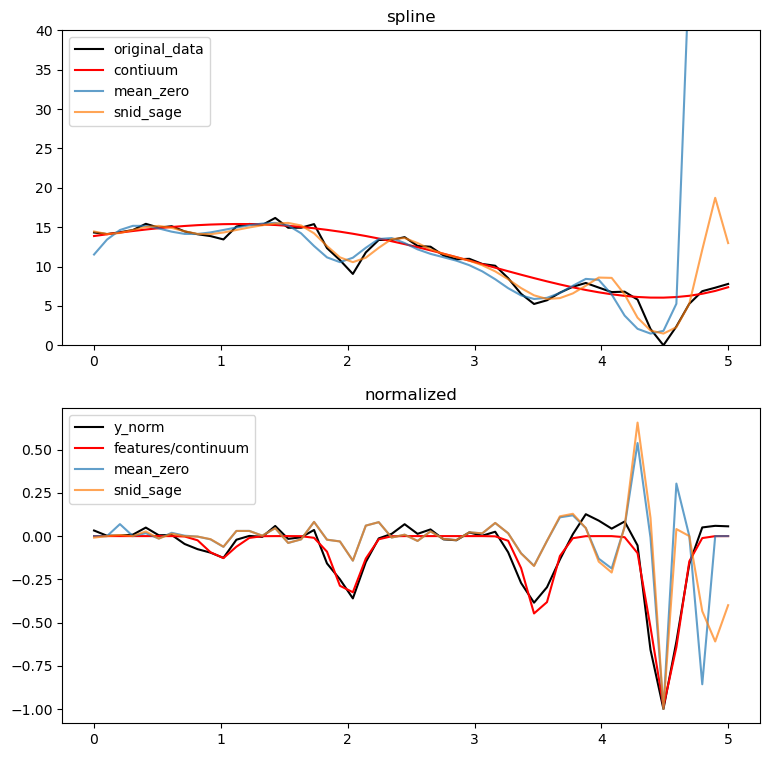

In [34]:
# Test with 4th order polynomial with noise and features
data_size= 50
x = np.linspace(0,5, num = data_size)

features = gaussian(x, -5, .1, 2) + gaussian(x, -2, .1, 1) + gaussian(x, -6, .1, 4.5) + gaussian(x, -4, .1, 3.5)
noise = np.random.normal(loc=0, scale=.5, size=(data_size))

continuum = np.polyval([.1,-.6,-.2,2.2,1.5], x)
y = continuum + noise + features
continuum, y = positive_flux(continuum, y)

# meanzero
ynorm, spline_interp, l1, l2, nknot, xknot, yknot = meanzero(y, nedge =2)
# snid sage
flat_sage, cont_sage = fit_continuum(y)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(9, 9))
ax1.plot(x, y, c = "k", label= "original_data")
ax1.plot(x, continuum, c = "r", label= "contiuum")
ax2.plot(x, y/continuum -1, c = "k", label="y_norm")
ax2.plot(x, features/continuum, c = "r", label="features/continuum")

#ax2.set_ylim(-3,3)
ax1.set_title("spline")
ax2.set_title("normalized")

# meanzero
ax1.plot(x[0:-2], 10**spline_interp(np.arange(0.5,data_size-2)), label = "mean_zero", alpha = 0.7) 
ax2.plot(x, ynorm, label = "mean_zero", alpha = 0.7)

# snid sage
ax1.plot(x, cont_sage, label = "snid_sage", alpha = 0.7)
ax2.plot(x, flat_sage, label = "snid_sage", alpha = 0.7)


ax1.legend()
ax2.legend()

ax1.set_ylim(0,40)


(0.0, 40.0)

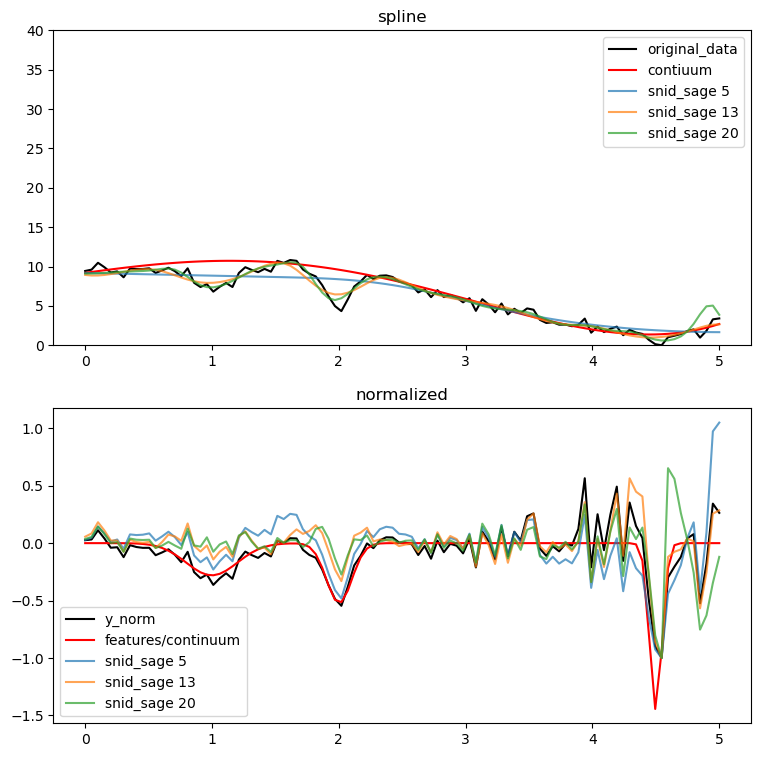

In [54]:
# Test with 4th order polynomial with noise and features
data_size= 100
x = np.linspace(0,5, num = data_size)

features = gaussian(x, -5, .1, 2) + gaussian(x, -3, .2, 1) + gaussian(x, -2, .05, 4.5)
noise = np.random.normal(loc=0, scale=0.5, size=(data_size))
continuum = np.polyval([.1,-.6,-.2,2.2,1.5], x)
y = continuum + noise + features
continuum, y = positive_flux(continuum, y)

# snid sage
flat_sage5, cont_sage5 = fit_continuum(y, knotnum = 5,edge_guard_frac = 0.05)
flat_sage13, cont_sage13 = fit_continuum(y, knotnum = 13)
flat_sage20, cont_sage20 = fit_continuum(y, knotnum = 25)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(9, 9))
ax1.plot(x, y, c = "k", label= "original_data")
ax1.plot(x, continuum, c = "r", label= "contiuum")
ax2.plot(x, y/continuum -1, c = "k", label="y_norm")
ax2.plot(x, features/continuum, c = "r", label="features/continuum")

#ax2.set_ylim(-3,3)
ax1.set_title("spline")
ax2.set_title("normalized")

# snid sage 5
ax1.plot(x, cont_sage5, label = "snid_sage 5", alpha = 0.7)
ax2.plot(x, flat_sage5, label = "snid_sage 5", alpha = 0.7)

# snid sage 13
ax1.plot(x, cont_sage13, label = "snid_sage 13", alpha = 0.7)
ax2.plot(x, flat_sage13, label = "snid_sage 13", alpha = 0.7)

# snid sage 5
ax1.plot(x, cont_sage20, label = "snid_sage 20", alpha = 0.7)
ax2.plot(x, flat_sage20, label = "snid_sage 20", alpha = 0.7)


ax1.legend()
ax2.legend()

ax1.set_ylim(0,40)


In [52]:
flat_sage20

array([ 2.00019963e-02, -2.76518465e-02, -5.34838429e-02,  1.83111020e-02,
        2.22044605e-16,  1.49026419e-01, -2.58527862e-02, -5.87247052e-02,
       -9.69164235e-02,  6.04840948e-02,  9.64892601e-02, -1.52375014e-02,
       -7.59878539e-02,  2.44456872e-02, -9.39872376e-02,  1.28547123e-01,
       -9.89379838e-02, -4.23811028e-02, -1.95410063e-02,  4.62234069e-02,
        2.01478804e-02,  1.47837531e-01, -5.13227927e-02, -1.21885837e-02,
       -1.11701874e-01,  6.47096868e-02,  2.07991018e-03, -4.32228357e-02,
       -4.90022495e-03, -3.02978816e-02, -1.51561136e-02,  2.61809831e-02,
        2.42252994e-02, -3.57141052e-02,  9.35943524e-02, -3.63421733e-02,
        9.13029588e-02, -3.86823673e-02,  4.67456681e-02, -1.14234364e-01,
       -1.00028752e-01, -3.06059125e-01, -1.62703943e-01,  2.84014159e-01,
        1.53490349e-01,  2.02623431e-02,  3.48934041e-02,  1.93665025e-02,
       -5.33592472e-02,  1.37614336e-02,  3.87549193e-02,  6.90026204e-02,
       -1.27138942e-01,  